In [175]:
import os
import datetime

import torch
import torch.utils.data
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from torch import nn, optim
from torch.nn import functional as F
from torchvision.utils import save_image
import numpy as np

In [176]:
RESULTS_PATH = "./results"
DISENTANGLEMENT_RANGE = [-2, 2]
DISENTANGLEMENT_STEPS = 8

hyperparameters = {
    "lr": 1e-3,
    "batch_size": 64,
    "num_epochs": 1000,
    "log_interval": 100,
    "latent_dim": 10,
    "early_stopping_rounds": 5,
    "early_stopping_min_delta": 1e-4,
    "device": 'cuda' if torch.cuda.is_available() else 'cpu'
}

In [177]:
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=True, download=True, transform=transforms.ToTensor()),
    batch_size=hyperparameters['batch_size'], shuffle=True)
val_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=False, transform=transforms.ToTensor()),
    batch_size=hyperparameters['batch_size'], shuffle=False)

# Data Exploration

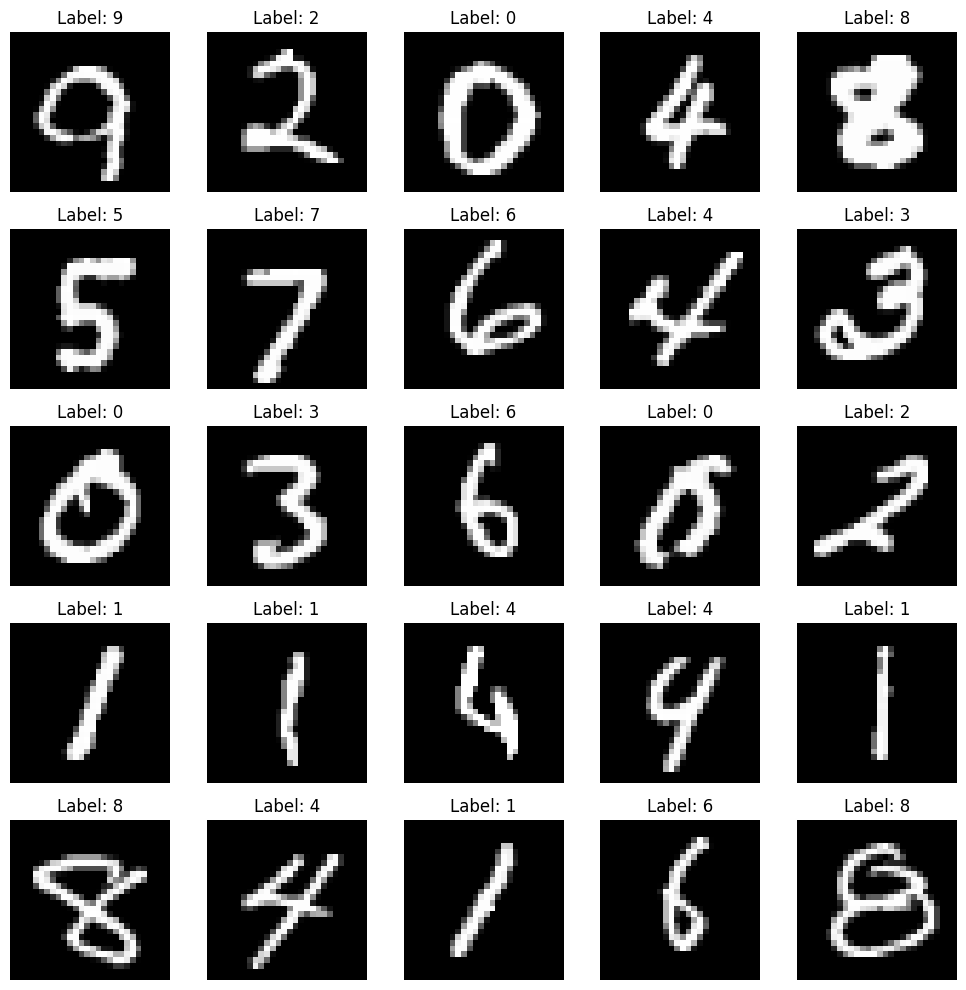

In [178]:
# Get a batch of images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Create a 5x5 grid
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
axes = axes.ravel()

# Plot 25 images
for idx in range(25):
    axes[idx].imshow(images[idx].squeeze(), cmap='gray')
    axes[idx].set_title(f'Label: {labels[idx]}')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Model

In [179]:
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        self.fc1 = nn.Linear(784, 400)
        self.fc21 = nn.Linear(400, hyperparameters['latent_dim'])
        self.fc22 = nn.Linear(400, hyperparameters['latent_dim'])
        self.fc3 = nn.Linear(hyperparameters['latent_dim'], 400)
        self.fc4 = nn.Linear(400, 784)

    def encode(self, x):
        h1 = F.relu(self.fc1(x.view(-1, 784)))
        return self.fc21(h1), self.fc22(h1) # return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x) # shape: [batch_size, 784]
        z = self.reparameterize(mu, logvar) # shape: [batch_size, hyperparameters['latent_dim']]
        return self.decode(z), mu, logvar

In [180]:
model = VAE().to(hyperparameters['device'])
optimizer = optim.Adam(model.parameters(), lr=hyperparameters['lr'])

# Training functions

In [181]:
# Reconstruction + KL divergence losses summed over all elements and batch
def loss_function(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')

    # see Appendix B from VAE paper:
    # Kingma and Welling. Auto-Encoding Variational Bayes. ICLR, 2014
    # https://arxiv.org/abs/1312.6114
    # 0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return BCE + KLD, BCE, KLD

def train(epoch):
    model.train()
    train_loss_total= train_bce_loss_total = train_kld_loss_total = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(hyperparameters['device'])
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss, bce_loss, kld_loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss_total += loss.item()
        train_bce_loss_total += bce_loss.item()
        train_kld_loss_total += kld_loss.item()
        optimizer.step()
        
        # Optional logging after certain log_interval
        # if batch_idx % hyperparameters['log_interval'] == 0:
        #     print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
        #         epoch, batch_idx * len(data), len(train_loader.dataset),
        #         100. * batch_idx / len(train_loader),
        #         loss.item() / len(data)))


    print('====> Epoch: {} Average train loss: {:.4f}'.format(
          epoch, train_loss_total / len(train_loader.dataset)))
    
    return train_bce_loss_total / len(train_loader.dataset), train_kld_loss_total / len(train_loader.dataset)


def validate(epoch, result_save_path):
    model.eval()
    val_loss_total = val_bce_loss_total = val_kld_loss_total = 0
    with torch.no_grad():
        for i, (data, _) in enumerate(val_loader):
            data = data.to(hyperparameters['device'])
            recon_batch, mu, logvar = model(data)
            loss, bce_loss, kld_loss = loss_function(recon_batch, data, mu, logvar)
            val_loss_total += loss.item()
            val_bce_loss_total += bce_loss.item()
            val_kld_loss_total += kld_loss.item()
            if i == 0:
                n = min(data.size(0), 8)
                comparison = torch.cat([data[:n], recon_batch.view(hyperparameters['batch_size'], 1, 28, 28)[:n]])
                save_image(comparison.cpu(), os.path.join(result_save_path, f"reconstruction_{str(epoch)}.png"), nrow=n)

    val_loss_total /= len(val_loader.dataset)
    print('====> Epoch: {} Average validation loss: {:.4f}'.format(epoch, val_loss_total))

    return val_bce_loss_total / len(val_loader.dataset), val_kld_loss_total / len(val_loader.dataset)

# Training

In [182]:
result_save_path = os.path.join(RESULTS_PATH, str(datetime.datetime.now()))
if not os.path.exists(result_save_path):
    os.makedirs(result_save_path)

train_bce_loss = []
train_kld_loss = []
val_bce_loss = []
val_kld_loss = []
no_epochs_no_improvement = 0
best_val_loss = np.inf

for epoch in range(1, hyperparameters['num_epochs'] + 1):
    train_losses = train(epoch)
    train_bce_loss.append(train_losses[0])
    train_kld_loss.append(train_losses[1])

    val_losses = validate(epoch, result_save_path)
    val_bce_loss.append(val_losses[0])
    val_kld_loss.append(val_losses[1])
    val_loss = val_losses[0] + val_losses[1]

    with torch.no_grad():
        sample = torch.randn(64, hyperparameters['latent_dim']).to(hyperparameters['device'])
        sample = model.decode(sample).cpu()
        save_image(sample.view(64, 1, 28, 28), os.path.join(result_save_path, f"sample_{str(epoch)}.png"))
    
    # early stopping:
    if best_val_loss - val_loss > hyperparameters['early_stopping_min_delta']: # only when there is a real improvement
        no_epochs_no_improvement = 0
        best_val_loss = val_loss
    else:
        no_epochs_no_improvement += 1
        print(f"No improvement for {no_epochs_no_improvement} epochs.")
        if no_epochs_no_improvement >= hyperparameters['early_stopping_rounds']:
            print(f"No improvement for {no_epochs_no_improvement} epochs. Aborted training due to early stopping.")
            break

====> Epoch: 1 Average loss: 147.3569
====> Validation set loss: 122.9288
====> Epoch: 2 Average loss: 120.8265
====> Validation set loss: 117.2672
====> Epoch: 3 Average loss: 116.9351
====> Validation set loss: 115.0082
====> Epoch: 4 Average loss: 114.9066
====> Validation set loss: 113.2707
====> Epoch: 5 Average loss: 113.5111
====> Validation set loss: 112.1979
====> Epoch: 6 Average loss: 112.5824
====> Validation set loss: 111.4505
====> Epoch: 7 Average loss: 111.7606
====> Validation set loss: 110.8434
====> Epoch: 8 Average loss: 111.1094
====> Validation set loss: 110.5282
====> Epoch: 9 Average loss: 110.4755
====> Validation set loss: 110.0097
====> Epoch: 10 Average loss: 109.9601
====> Validation set loss: 109.3815
====> Epoch: 11 Average loss: 109.4936
====> Validation set loss: 109.4256
No improvement for 1 epochs.
====> Epoch: 12 Average loss: 109.1217
====> Validation set loss: 108.6601
====> Epoch: 13 Average loss: 108.7587
====> Validation set loss: 108.6049
====>

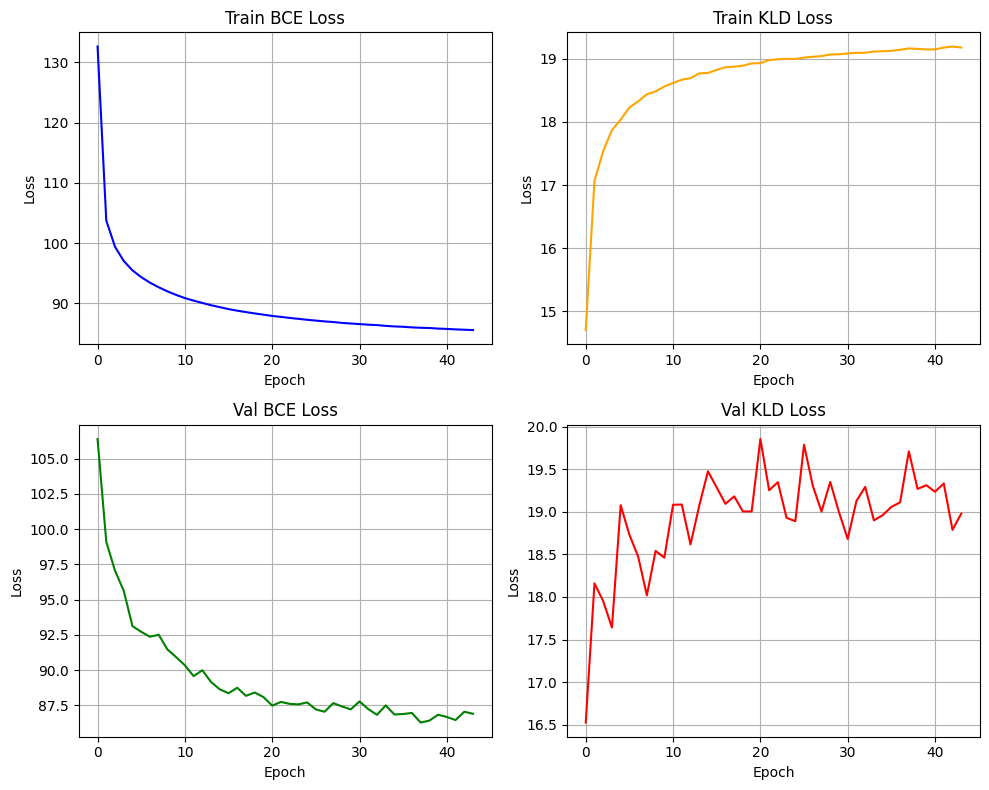

In [183]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
epochs = list(range(len(train_bce_loss)))

# 1: Train BCE
axs[0, 0].plot(epochs, train_bce_loss, label='Train BCE', color='blue')
axs[0, 0].set_title('Train BCE Loss')
axs[0, 0].set_xlabel('Epoch')
axs[0, 0].set_ylabel('Loss')
axs[0, 0].grid(True)

# 2: Train KLD
axs[0, 1].plot(epochs, train_kld_loss, label='Train KLD', color='orange')
axs[0, 1].set_title('Train KLD Loss')
axs[0, 1].set_xlabel('Epoch')
axs[0, 1].set_ylabel('Loss')
axs[0, 1].grid(True)

# 3: Val BCE
axs[1, 0].plot(epochs, val_bce_loss, label='Val BCE', color='green')
axs[1, 0].set_title('Val BCE Loss')
axs[1, 0].set_xlabel('Epoch')
axs[1, 0].set_ylabel('Loss')
axs[1, 0].grid(True)

# 4: Val KLD
axs[1, 1].plot(epochs, val_kld_loss, label='Val KLD', color='red')
axs[1, 1].set_title('Val KLD Loss')
axs[1, 1].set_xlabel('Epoch')
axs[1, 1].set_ylabel('Loss')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Visualization

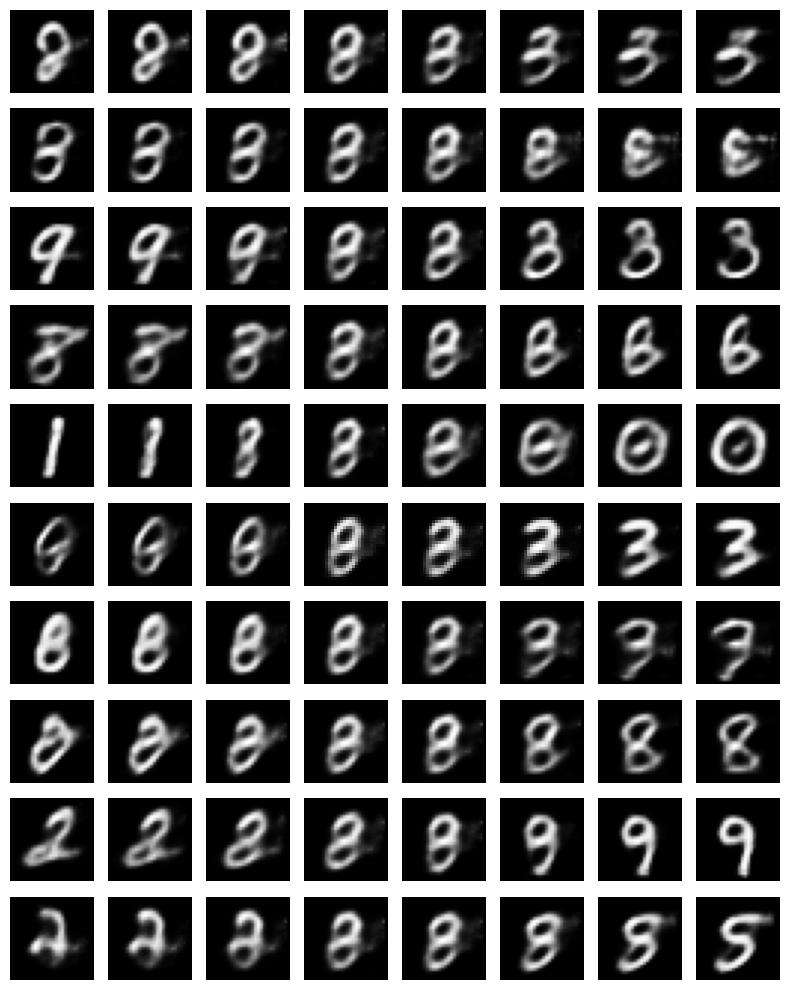

In [184]:
imgs = []
with torch.no_grad():
    z = torch.zeros(hyperparameters['latent_dim'])
    for z_param in range(hyperparameters['latent_dim']):
        row_imgs = []
        for val in torch.linspace(DISENTANGLEMENT_RANGE[0], DISENTANGLEMENT_RANGE[1], DISENTANGLEMENT_STEPS): # tensor with DISENTANGLEMENT_STEPS values ranging from DISENTANGLEMENT_RANGE[0] to DISENTANGLEMENT_RANGE[1]
            z_copy = z.clone()
            z_copy[z_param] = val  # nur eine Dimension ändern
            img = model.decode(z_copy.unsqueeze(0)) # add batch dimension
            row_imgs.append(img.view(28, 28).cpu().numpy()) # MNIST: 28x28
        imgs.append(row_imgs)
        

# Plot
fig, axes = plt.subplots(nrows=hyperparameters['latent_dim'], ncols=DISENTANGLEMENT_STEPS, figsize=(DISENTANGLEMENT_STEPS, hyperparameters['latent_dim']))

for dim in range(hyperparameters['latent_dim']):
    for step in range(DISENTANGLEMENT_STEPS):
        ax = axes[dim, step]
        ax.imshow(imgs[dim][step], cmap='gray')
        ax.axis('off')

plt.tight_layout()
plt.show()

# Experimenting

In [185]:
torch.linspace(DISENTANGLEMENT_RANGE[0], DISENTANGLEMENT_RANGE[1], DISENTANGLEMENT_STEPS)

tensor([-2.0000, -1.4286, -0.8571, -0.2857,  0.2857,  0.8571,  1.4286,  2.0000])

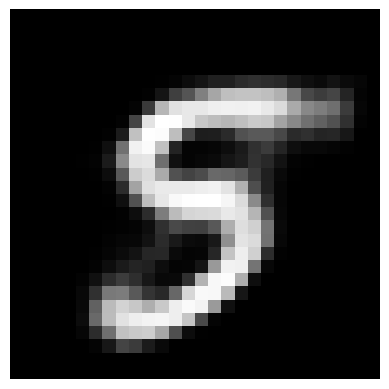

In [186]:

z_test = torch.rand([-0.4, 2.0, -2.0, 2.0, -0.8, -2.0, -1.4, 2.0, 1.8, 0.8]).to(hyperparameters['device'])
img = model.decode(z_copy.unsqueeze(0))
img = img.view(28, 28).detach().cpu().numpy()
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()